In [24]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import urllib.request

In [25]:
def _to_float01(rgb):
    rgb = np.asarray(rgb)
    if rgb.dtype.kind in "ui":
        rgb = rgb.astype(np.float64) / 255.0
    else:
        rgb = rgb.astype(np.float64)
    return np.clip(rgb, 0.0, 1.0)

In [26]:
def rgb_to_hsv_np(rgb):
    x = _to_float01(rgb)
    r, g, b = x[..., 0], x[..., 1], x[..., 2]

    cmax = np.maximum(np.maximum(r, g), b)
    cmin = np.minimum(np.minimum(r, g), b)
    d = cmax - cmin

    v = cmax

    s = np.zeros_like(cmax)
    mask_s = cmax > 0
    s[mask_s] = d[mask_s] / cmax[mask_s]

    h = np.zeros_like(cmax)
    mask = d > 0

    mask_r = mask & (cmax == r)
    mask_g = mask & (cmax == g)
    mask_b = mask & (cmax == b)

    h[mask_r] = ((g[mask_r] - b[mask_r]) / d[mask_r]) % 6.0
    h[mask_g] = ((b[mask_g] - r[mask_g]) / d[mask_g]) + 2.0
    h[mask_b] = ((r[mask_b] - g[mask_b]) / d[mask_b]) + 4.0

    h = (h / 6.0) % 1.0

    return np.stack([h, s, v], axis=-1)

In [27]:
def rgb_to_hsl_np(rgb):
    x = _to_float01(rgb)
    r, g, b = x[..., 0], x[..., 1], x[..., 2]

    cmax = np.maximum(np.maximum(r, g), b)
    cmin = np.minimum(np.minimum(r, g), b)
    d = cmax - cmin

    l = (cmax + cmin) / 2.0

    s = np.zeros_like(l)
    denom = 1.0 - np.abs(2.0 * l - 1.0)
    mask_s = (d > 0.0) & (denom > 0.0)
    s[mask_s] = d[mask_s] / denom[mask_s]

    h = np.zeros_like(l)
    mask = d > 0.0

    mask_r = mask & (cmax == r)
    mask_g = mask & (cmax == g)
    mask_b = mask & (cmax == b)

    h[mask_r] = ((g[mask_r] - b[mask_r]) / d[mask_r]) % 6.0
    h[mask_g] = ((b[mask_g] - r[mask_g]) / d[mask_g]) + 2.0
    h[mask_b] = ((r[mask_b] - g[mask_b]) / d[mask_b]) + 4.0

    h = (h / 6.0) % 1.0

    return np.stack([h, s, l], axis=-1)

In [28]:
def load_image_bgr_from_url(url):
    data = urllib.request.urlopen(url).read()
    arr = np.frombuffer(data, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_COLOR)
    return img

In [29]:
def normalize_opencv_hsv(hsv_bgr):
    h = hsv_bgr[..., 0].astype(np.float64) / 180.0
    s = hsv_bgr[..., 1].astype(np.float64) / 255.0
    v = hsv_bgr[..., 2].astype(np.float64) / 255.0
    return np.stack([h, s, v], axis=-1)

In [30]:
def normalize_opencv_hls(hls_bgr):
    h = hls_bgr[..., 0].astype(np.float64) / 180.0
    l = hls_bgr[..., 1].astype(np.float64) / 255.0
    s = hls_bgr[..., 2].astype(np.float64) / 255.0
    return np.stack([h, s, l], axis=-1)

In [31]:
urls = [
    "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fzefirka.club%2Fwallpapers%2Fuploads%2Fposts%2F2023-03%2F1678024684_zefirka-club-p-oboi-dlya-rabochego-stola-krasnaya-mashina-7.jpg&f=1&nofb=1&ipt=1da75dd3e819100e8d793a6e3b8287409c3d6ca4ef58697c248046a7f95769fe",
    "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Findiecatorhome.files.wordpress.com%2F2023%2F08%2Flinus-e1692337608336.jpg%3Fw%3D1024&f=1&nofb=1&ipt=c2cc0a8a5b62f13dd45d19f721fff3f4c5c3fcd015f7dfe11f998a87b322fc7d",
    "https://external-content.duckduckgo.com/iu/?u=https%3A%2F%2Fi.ytimg.com%2Fvi%2FSp1HQeBHjhM%2Fmaxresdefault.jpg&f=1&nofb=1&ipt=3898bafc8bbe94ca1e4da202567248ddd9f765425045a159acdf88072a07e0a3",
]

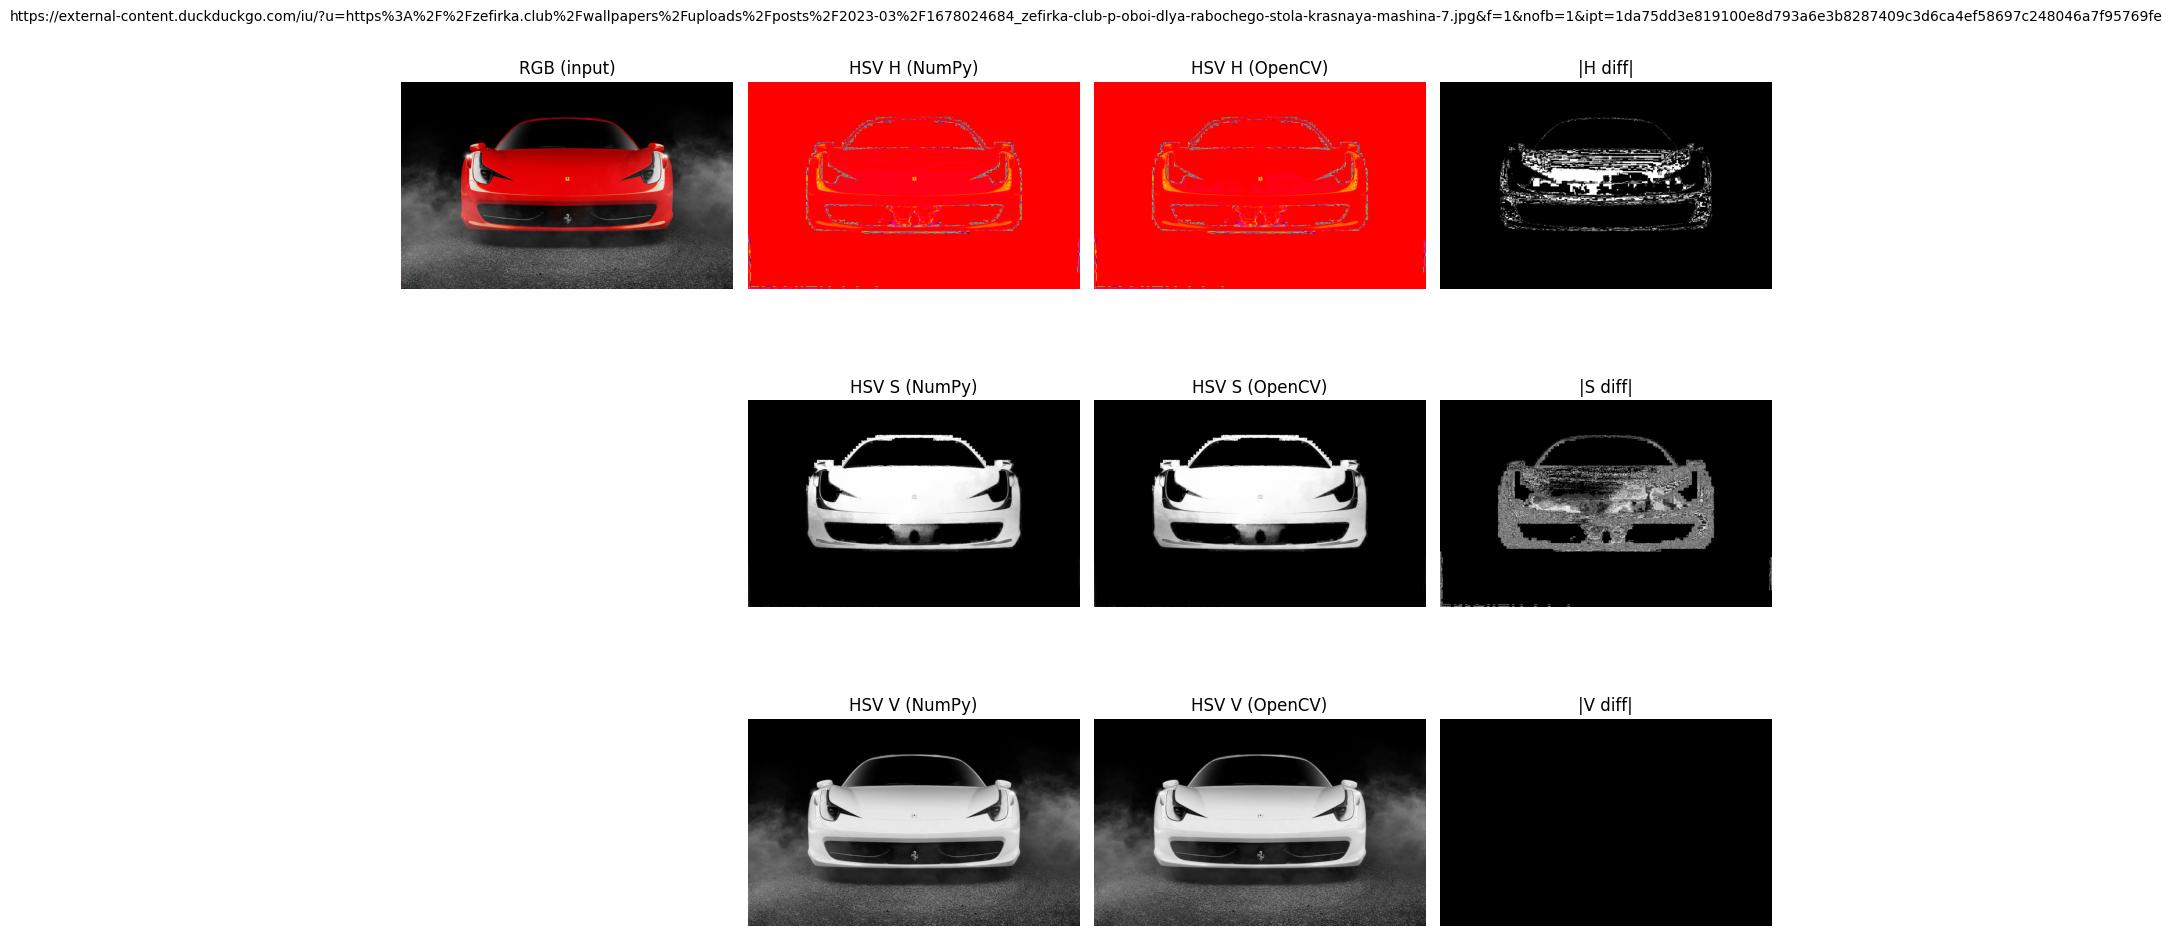

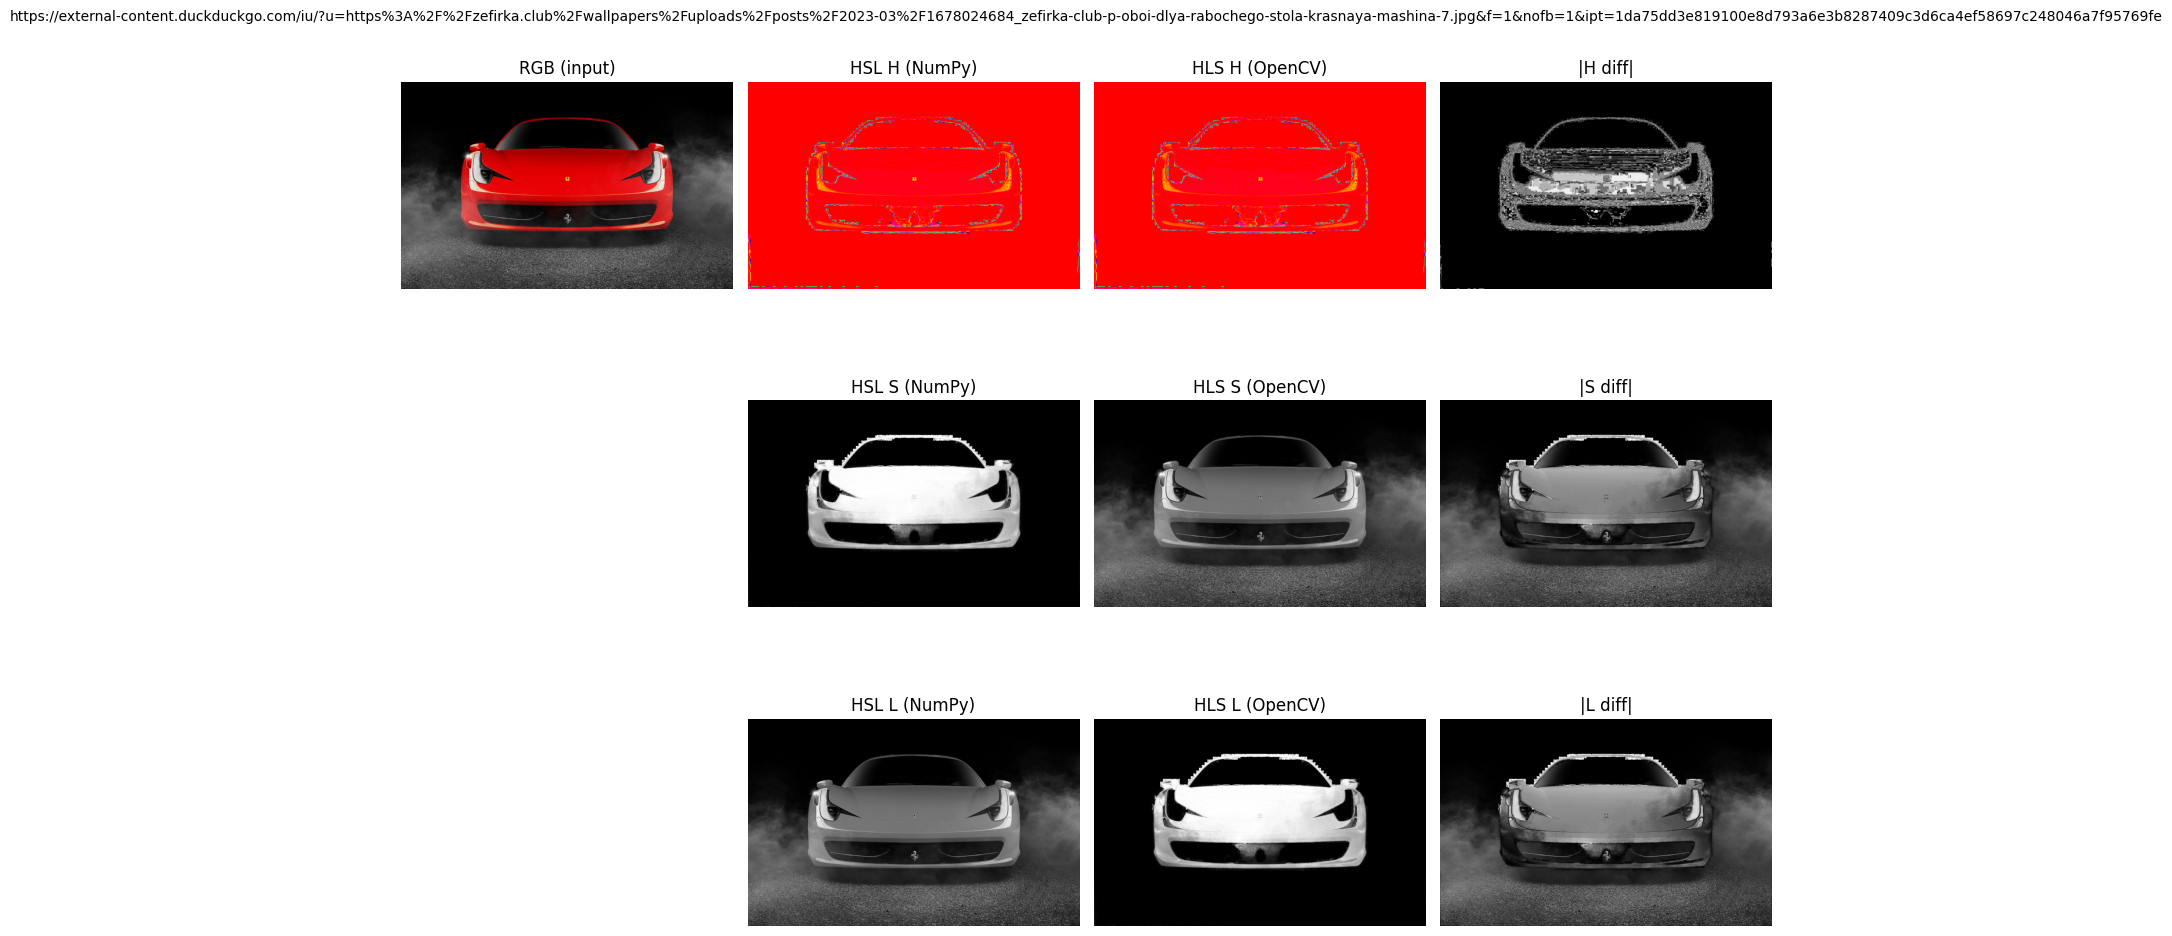

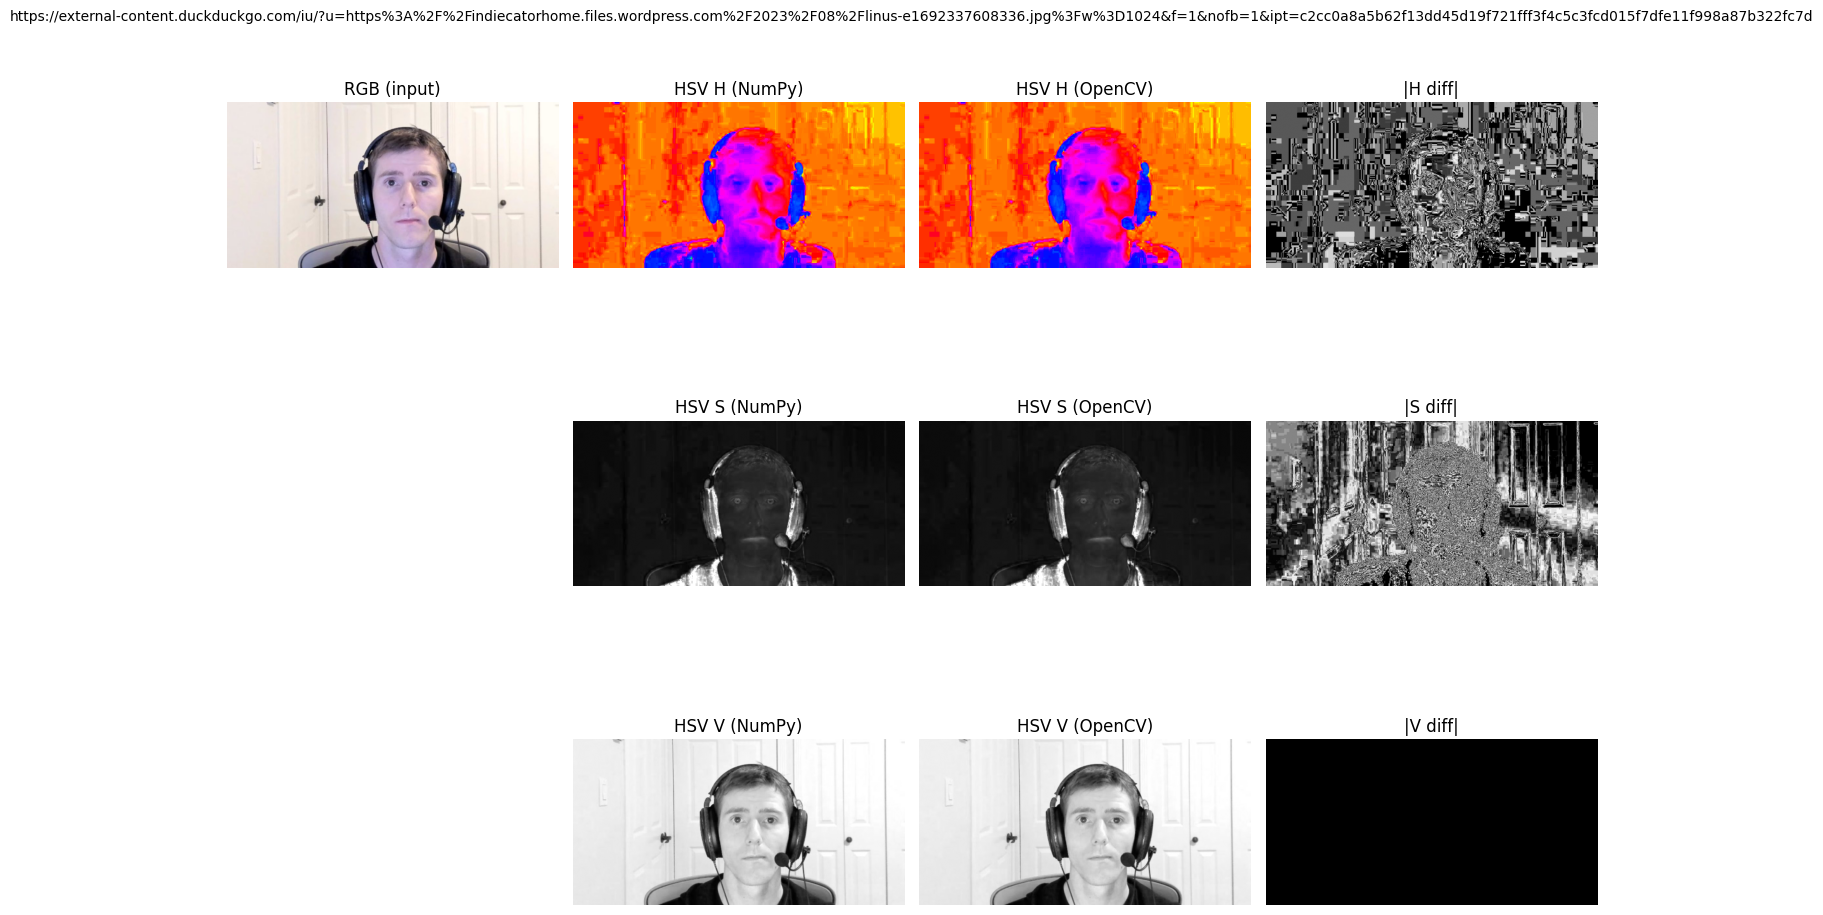

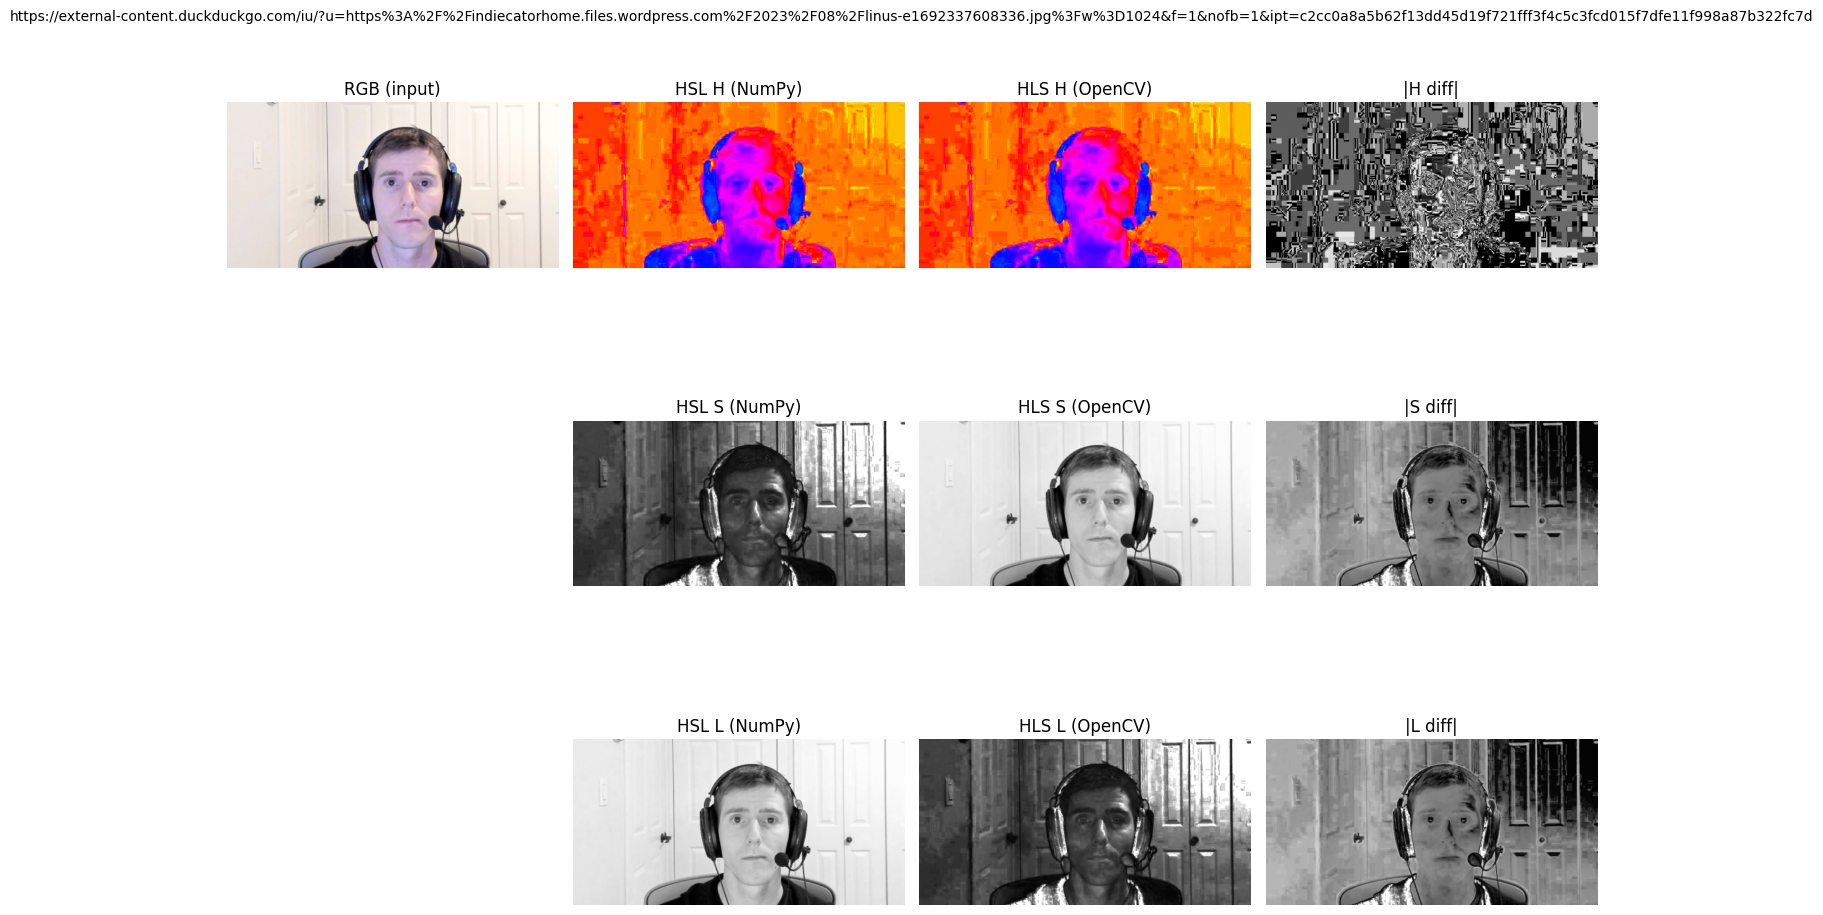

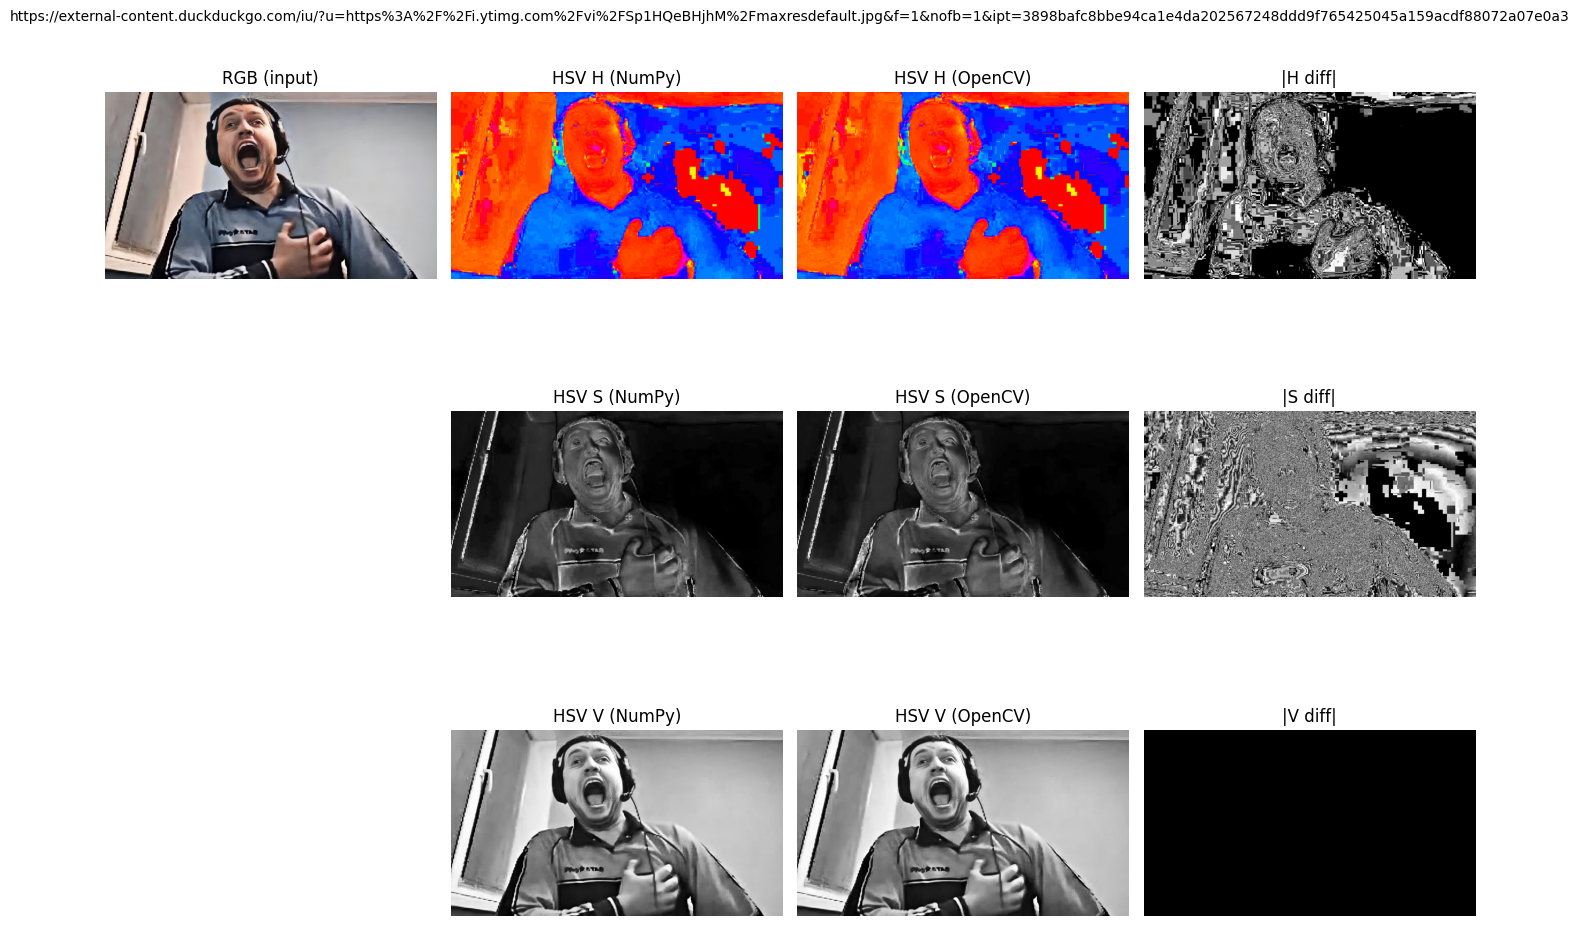

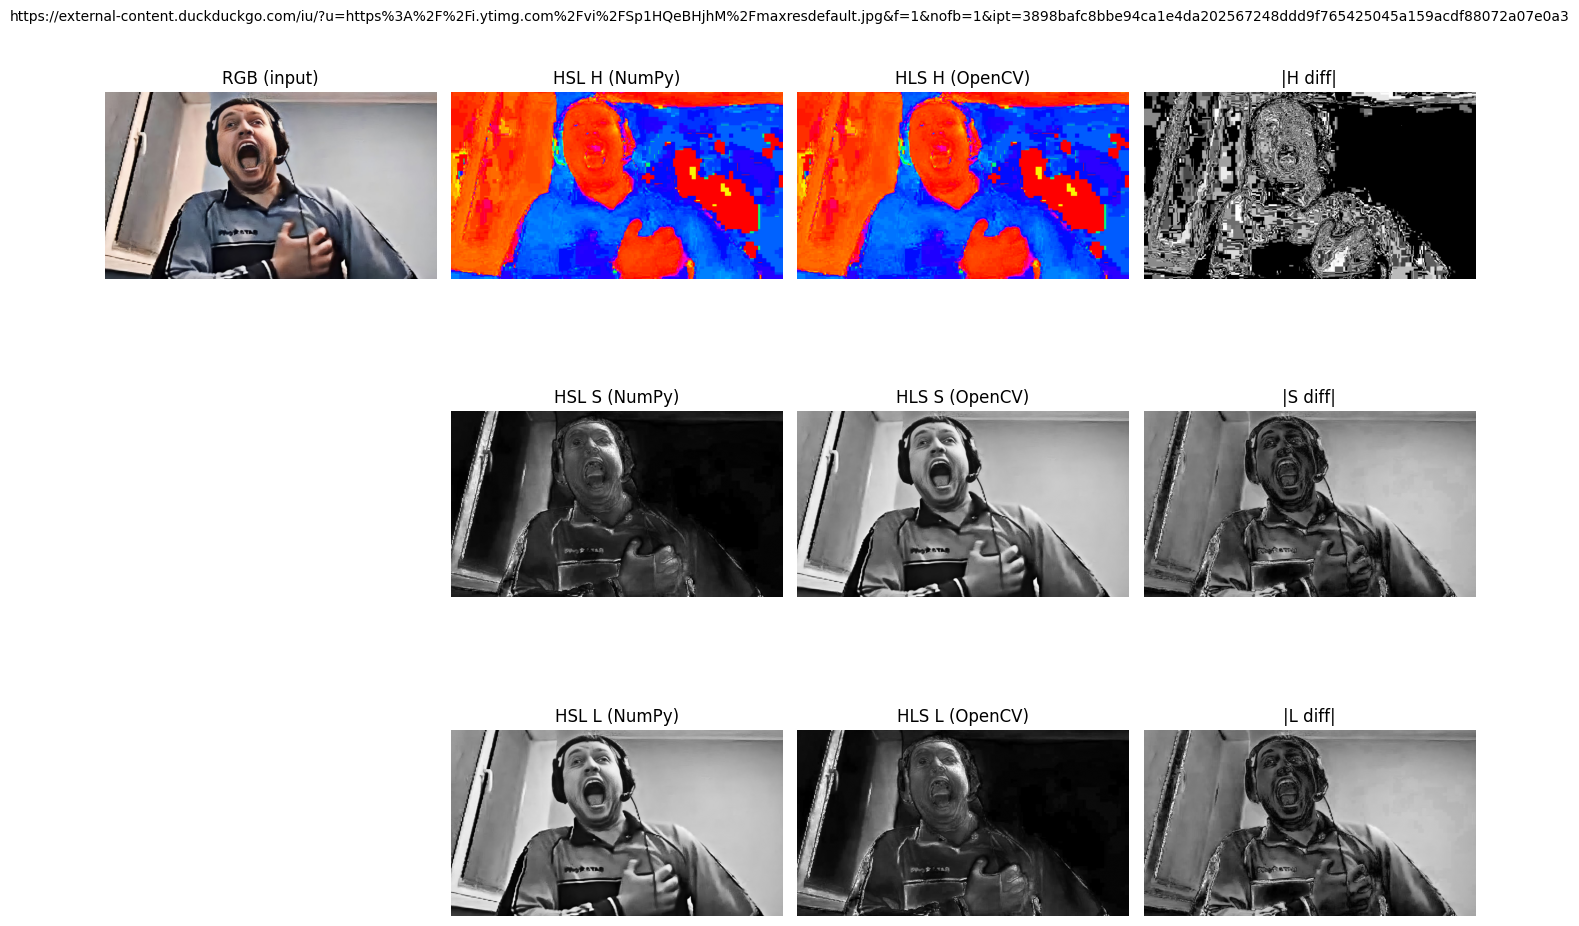

In [32]:
for url in urls:
    bgr = load_image_bgr_from_url(url)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    hsv_np = rgb_to_hsv_np(rgb)
    hsl_np = rgb_to_hsl_np(rgb)

    hsv_cv = normalize_opencv_hsv(cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV))
    hls_cv = normalize_opencv_hls(cv2.cvtColor(bgr, cv2.COLOR_BGR2HLS))

    fig = plt.figure(figsize=(14, 10))

    ax = plt.subplot(3, 4, 1)
    ax.imshow(rgb)
    ax.set_title("RGB (input)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 2)
    ax.imshow(hsv_np[..., 0], cmap="hsv")
    ax.set_title("HSV H (NumPy)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 3)
    ax.imshow(hsv_cv[..., 0], cmap="hsv")
    ax.set_title("HSV H (OpenCV)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 4)
    ax.imshow(np.abs(hsv_np[..., 0] - hsv_cv[..., 0]), cmap="gray")
    ax.set_title("|H diff|")
    ax.axis("off")

    ax = plt.subplot(3, 4, 6)
    ax.imshow(hsv_np[..., 1], cmap="gray")
    ax.set_title("HSV S (NumPy)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 7)
    ax.imshow(hsv_cv[..., 1], cmap="gray")
    ax.set_title("HSV S (OpenCV)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 8)
    ax.imshow(np.abs(hsv_np[..., 1] - hsv_cv[..., 1]), cmap="gray")
    ax.set_title("|S diff|")
    ax.axis("off")

    ax = plt.subplot(3, 4, 10)
    ax.imshow(hsv_np[..., 2], cmap="gray")
    ax.set_title("HSV V (NumPy)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 11)
    ax.imshow(hsv_cv[..., 2], cmap="gray")
    ax.set_title("HSV V (OpenCV)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 12)
    ax.imshow(np.abs(hsv_np[..., 2] - hsv_cv[..., 2]), cmap="gray")
    ax.set_title("|V diff|")
    ax.axis("off")

    fig.suptitle(url, fontsize=10)
    plt.tight_layout()
    plt.show()

    fig = plt.figure(figsize=(14, 10))

    ax = plt.subplot(3, 4, 1)
    ax.imshow(rgb)
    ax.set_title("RGB (input)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 2)
    ax.imshow(hsl_np[..., 0], cmap="hsv")
    ax.set_title("HSL H (NumPy)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 3)
    ax.imshow(hls_cv[..., 0], cmap="hsv")
    ax.set_title("HLS H (OpenCV)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 4)
    ax.imshow(np.abs(hsl_np[..., 0] - hls_cv[..., 0]), cmap="gray")
    ax.set_title("|H diff|")
    ax.axis("off")

    ax = plt.subplot(3, 4, 6)
    ax.imshow(hsl_np[..., 1], cmap="gray")
    ax.set_title("HSL S (NumPy)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 7)
    ax.imshow(hls_cv[..., 2], cmap="gray")
    ax.set_title("HLS S (OpenCV)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 8)
    ax.imshow(np.abs(hsl_np[..., 1] - hls_cv[..., 2]), cmap="gray")
    ax.set_title("|S diff|")
    ax.axis("off")

    ax = plt.subplot(3, 4, 10)
    ax.imshow(hsl_np[..., 2], cmap="gray")
    ax.set_title("HSL L (NumPy)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 11)
    ax.imshow(hls_cv[..., 1], cmap="gray")
    ax.set_title("HLS L (OpenCV)")
    ax.axis("off")

    ax = plt.subplot(3, 4, 12)
    ax.imshow(np.abs(hsl_np[..., 2] - hls_cv[..., 1]), cmap="gray")
    ax.set_title("|L diff|")
    ax.axis("off")

    fig.suptitle(url, fontsize=10)
    plt.tight_layout()
    plt.show()